In [ ]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from helpers.config import *

import warnings
warnings.filterwarnings("ignore")

In [35]:
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "text.usetex": False,
    "font.family": "serif"
})

In [4]:
with h5py.File(glitch_lm_dataset_path, 'r') as h5:
    #glitches = h5['QT'][:]
    level_lm = h5['level'][:]
    beta_lm = h5['beta'][:]

with h5py.File(glitch_hm_dataset_path, 'r') as h5:
    #glitches = h5['QT'][:]
    level_hm = h5['level'][:]
    beta_hm = h5['beta'][:]

with h5py.File(glitch_ehm_dataset_path, 'r') as h5:
    #glitches = h5['QT'][:]
    level_ehm = h5['level'][:]
    beta_ehm = h5['beta'][:]

data = np.loadtxt(lpf_ord_param_path, skiprows=1)

lpf_betas = data[:, 0]
lpf_levels = data[:, 1]

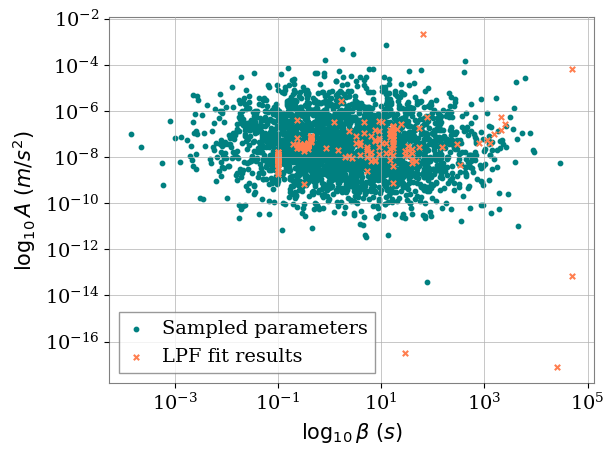

In [37]:
level = np.concatenate((level_lm, level_hm, level_ehm))
beta = np.concatenate((beta_lm, beta_hm, beta_ehm))

plt.figure(tight_layout=True)
plt.scatter(beta, level, color='teal', s=10, label='Sampled parameters')
plt.scatter(lpf_betas, lpf_levels*1e5, color='coral', s=15, marker='x', label='LPF fit results')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('$\log_{10}A\ (m/s^2)$')
plt.xlabel('$\log_{10}\\beta\ (s)$')
plt.legend(loc='lower left')
plt.savefig(DIST/'figures'/'glitch_params.png')
plt.show()